# **Classifier**
## **Data Loading**

In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [2]:
mutation = pd.read_csv('OmicsSomaticMutations.csv')
expression = pd.read_csv('OmicsExpressionProteinCodingGenesTPMLogp1.csv')
info = pd.read_csv('Model.csv')
expression = expression.rename(columns={'Unnamed: 0': 'ModelID'})
mutation = mutation[mutation.HugoSymbol == 'TP53'] # filter for TP53 mutations
expression['Mutation'] = expression['ModelID'].isin(mutation['ModelID']).astype(int) 
# here we only consider whether there is mutation or not, maybe include other stuff later

/var/folders/bm/yxd_5px52t5d6m_z9t3mp9400000gn/T/ipykernel_9077/1318940185.py:1: DtypeWarning: Columns (22,50,56,57,58,59,61) have mixed types. Specify dtype option on import or set low_memory=False.
  mutation = pd.read_csv('OmicsSomaticMutations.csv')


## **PCA**

In [3]:
X = expression.drop(columns=['ModelID'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)  
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.10673662 0.06622514 0.04807285]


/var/folders/bm/yxd_5px52t5d6m_z9t3mp9400000gn/T/ipykernel_7250/2872959061.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(X_pca[:, 0], X_pca[:, 1], c=expression.Mutation, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('viridis', 10))


Text(0, 0.5, 'component 2')

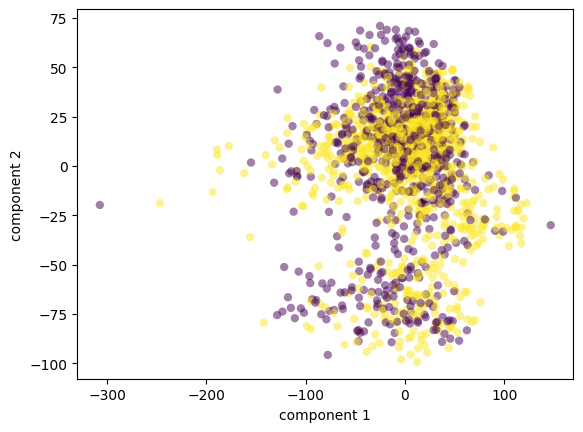

In [4]:
import matplotlib.pyplot as plt

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=expression.Mutation, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('viridis', 10))
plt.xlabel('component 1')
plt.ylabel('component 2')

/var/folders/bm/yxd_5px52t5d6m_z9t3mp9400000gn/T/ipykernel_7250/1743643603.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.scatter3D(x, y, z, cmap=plt.cm.get_cmap('viridis', 10),c=expression.Mutation)


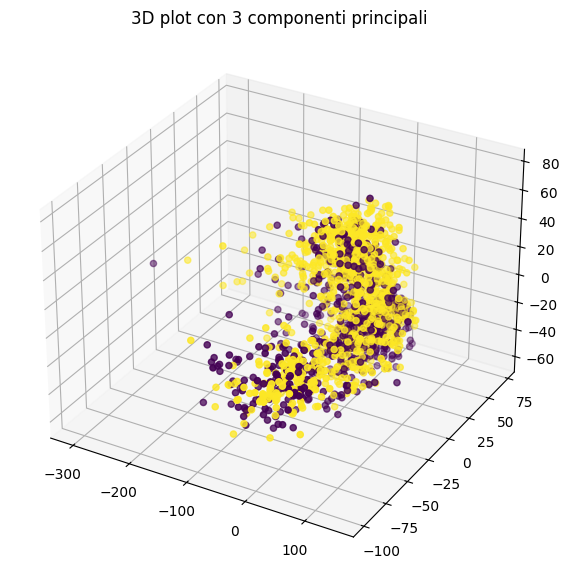

In [5]:
#### TBD da saltare per ora
# Creating figureax = plt.axes(projection ="3d")
from mpl_toolkits.mplot3d import Axes3D # <--- This is important for 3d plotting

x=X_pca[:, 0]
y=X_pca[:, 1]
z=X_pca[:, 2]
fig= plt.figure(figsize= (10, 7))
ax = plt.axes(projection="3d")
# Creating plot
ax.scatter3D(x, y, z, cmap=plt.cm.get_cmap('viridis', 10),c=expression.Mutation)
plt.title("3D plot con 3 componenti principali")
# show plotfrom mpl_toolkits.mplot3d import Axes3D # <--- This is important for 3d plotting
plt.show()

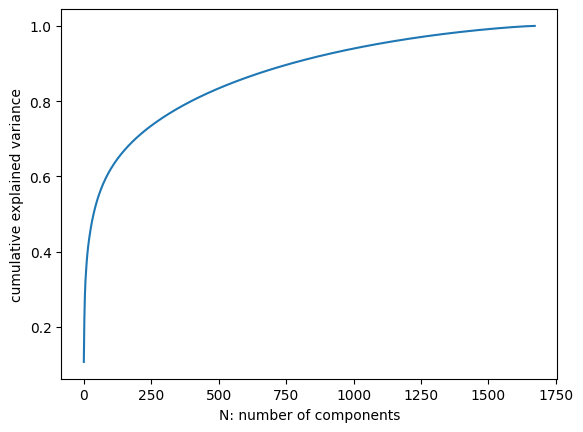

In [ ]:
import numpy as np 
pca = PCA().fit(X_scaled) # PCA() e' default per tutte le componenti
plt.plot(np.cumsum(pca.explained_variance_ratio_)) # sulle varianze normalizzate al totale
plt.xlabel('N: number of components')
plt.ylabel('cumulative explained variance')

In [ ]:
feature_names = X.columns

components = pca.components_

n_top = 10  # Top 10 features
for i, comp in enumerate(components):
    top_indices = np.argsort(np.abs(comp))[::-1][:n_top]
    top_features = feature_names[top_indices]
    top_weights = comp[top_indices]
    
    print(f"\nTop {n_top} features for PC{i+1}:")
    for feat, weight in zip(top_features, top_weights):
        print(f"{feat}: {weight:.4f}")


Top 10 features for PC1:
TARDBP (23435): 0.0182
SMC1A (8243): 0.0178
KPNB1 (3837): 0.0178
RBM12 (10137): 0.0176
DDX46 (9879): 0.0176
HCFC1 (3054): 0.0176
GPATCH8 (23131): 0.0175
TNRC6A (27327): 0.0175
CKAP5 (9793): 0.0174
UBTF (7343): 0.0173

Top 10 features for PC2:
GNG12 (55970): 0.0246
FAM114A1 (92689): 0.0244
GPX8 (493869): 0.0241
TNFRSF12A (51330): 0.0240
PARVA (55742): 0.0237
FKBP9 (11328): 0.0236
CD151 (977): 0.0234
NIBAN2 (64855): 0.0233
CCN1 (3491): 0.0232
ITGB5 (3693): 0.0232

Top 10 features for PC3:
LLGL2 (3993): 0.0288
ESRP2 (80004): 0.0280
ELMO3 (79767): 0.0279
CRB3 (92359): 0.0279
SH2D3A (10045): 0.0274
ARRDC1 (92714): 0.0274
ELF3 (1999): 0.0273
IQANK1 (642574): 0.0271
PKP3 (11187): 0.0271
CLDN4 (1364): 0.0270


## **Classifiers**

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel, RFE
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA


In [4]:
X = expression.drop(['ModelID', 'Mutation'], axis=1)
y = expression['Mutation']

# Keep column names for later feature importance analysis
feature_names = X.columns.tolist()

# 4. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Display class distribution
print(f"Training set: Class 0 (WT): {sum(y_train==0)}, Class 1 (Mutated): {sum(y_train==1)}")
print(f"Testing set: Class 0 (WT): {sum(y_test==0)}, Class 1 (Mutated): {sum(y_test==1)}")

Training set: Class 0 (WT): 549, Class 1 (Mutated): 789
Testing set: Class 0 (WT): 138, Class 1 (Mutated): 197


In [5]:
def evaluate_model(trained_model, X_test, y_test):
    y_pred = trained_model.predict(X_test)
    print("Confusion Matrix:")  
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("ROC AUC Score:", roc_auc_score(y_test, trained_model.predict_proba(X_test)[:, 1]))

    return None

In [9]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=0)
clf.fit(X_train, y_train)

evaluate_model(clf, X_test, y_test)

Confusion Matrix:
[[119  19]
 [ 19 178]]
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       138
           1       0.90      0.90      0.90       197

    accuracy                           0.89       335
   macro avg       0.88      0.88      0.88       335
weighted avg       0.89      0.89      0.89       335

ROC AUC Score: 0.928786875597734


/Users/beatricecitterio/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train) 

evaluate_model(rf, X_test, y_test)

Confusion Matrix:
[[102  36]
 [ 24 173]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.74      0.77       138
           1       0.83      0.88      0.85       197

    accuracy                           0.82       335
   macro avg       0.82      0.81      0.81       335
weighted avg       0.82      0.82      0.82       335

ROC AUC Score: 0.8932354888545575


In [ ]:
import xgboost as xgb

model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

evaluate_model(model, X_test, y_test)

/Users/beatricecitterio/opt/anaconda3/lib/python3.8/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


Confusion Matrix:
[[114  24]
 [ 14 183]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86       138
           1       0.88      0.93      0.91       197

    accuracy                           0.89       335
   macro avg       0.89      0.88      0.88       335
weighted avg       0.89      0.89      0.89       335

ROC AUC Score: 0.9472890458324138


In [ ]:
X_scaled = StandardScaler().fit_transform(expression.drop(columns=['ModelID', 'Mutation']))
X_pca = PCA(n_components=100).fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(
        X_pca, y, test_size=0.2, random_state=42, stratify=y
    )

model = LogisticRegression(random_state=0)
model.fit(X_train, y_train)

evaluate_model(model, X_test, y_test)